Title - Breast Cancer Detection System using Simple Neural Networks. Use Tensorflow and keras to create a neural network to detect possibility of breast cancer

1. Import Necessary Libraries

In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import os
import json
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import random
SEED = 42
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

BASE_DIR    = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH   = os.path.join(BASE_DIR, 'data',   'breast_cancer.csv')
MODEL_PATH  = os.path.join(BASE_DIR, 'models', 'saved_model.keras')
PLOTS_DIR   = os.path.join(BASE_DIR, 'outputs', 'plots')
METRICS_DIR = os.path.join(BASE_DIR, 'outputs', 'metrics')
PREDS_DIR   = os.path.join(BASE_DIR, 'outputs', 'predictions')

for d in [PLOTS_DIR, METRICS_DIR, PREDS_DIR,
          os.path.join(BASE_DIR, 'models')]:
    os.makedirs(d, exist_ok=True)

print('All libraries imported successfully!')
print(f'   NumPy      {np.__version__}')
print(f'   Pandas     {pd.__version__}')
print(f'   TensorFlow {tf.__version__}')
print(f'   Matplotlib {plt.matplotlib.__version__}')
print(f'\nOutput directories ready.')

All libraries imported successfully!
   NumPy      2.3.5
   Pandas     2.3.3
   TensorFlow 2.21.0
   Matplotlib 3.10.6

Output directories ready.


2. Loading the Dataset

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Data path : {DATA_PATH}\n')
df.head()

Dataset loaded: 569 rows × 32 columns
Data path : c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\data\breast_cancer.csv



,diagnosis,diagnosis_label,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,0,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,0,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,0,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


3. Exploratory Data Analysis

In [5]:
print(f'  Shape          : {df.shape}')
print(f'  Feature count  : {df.shape[1] - 2}  (excl. target columns)')
print(f'  Sample count   : {df.shape[0]}')
print(f'  Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('\n  Column Data Types:')
print(df.dtypes.value_counts().to_string())

  Shape          : (569, 32)
  Feature count  : 30  (excl. target columns)
  Sample count   : 569
  Memory usage   : 165.7 KB

  Column Data Types:
float64    30
int64       1
object      1


In [6]:
feature_cols = [c for c in df.columns if c not in ['diagnosis', 'diagnosis_label']]
df[feature_cols].describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


In [7]:
#Check for missing values

missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found! Dataset is clean.')
else:
    print(f'Missing values detected:')
    print(missing_df)

No missing values found! Dataset is clean.


In [9]:
class_counts = df['diagnosis_label'].value_counts()
class_pct    = df['diagnosis_label'].value_counts(normalize=True).mul(100).round(2)

print('Class Distribution:')
print('─' * 35)
for label, count, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    name = 'Benign (B)   ' if label == 'B' else 'Malignant (M)'
    bar  = '[]' * int(pct / 2)
    print(f'  {name}  {count:>4}  ({pct:>5.1f}%)  {bar}')
print('─' * 35)
print(f'  Total         :  {len(df)}')
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'  Imbalance ratio: {imbalance_ratio:.2f} : 1')

Class Distribution:
───────────────────────────────────
  Benign (B)      357  ( 62.7%)  [][][][][][][][][][][][][][][][][][][][][][][][][][][][][][][]
  Malignant (M)   212  ( 37.3%)  [][][][][][][][][][][][][][][][][][]
───────────────────────────────────
  Total         :  569
  Imbalance ratio: 1.68 : 1


4. Data Visualization

In [ ]:
def save_plot(filename, dpi=150):
    """Save current figure to outputs/plots/ directory."""
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'   💾 Saved → {path}')

COLORS = {'B': '#2196F3', 'M': '#F44336'}   # Blue = Benign, Red = Malignant
PALETTE = ['#2196F3', '#F44336']

print('Colour palette defined. Starting visualizations…')

Colour palette defined. Starting visualizations…


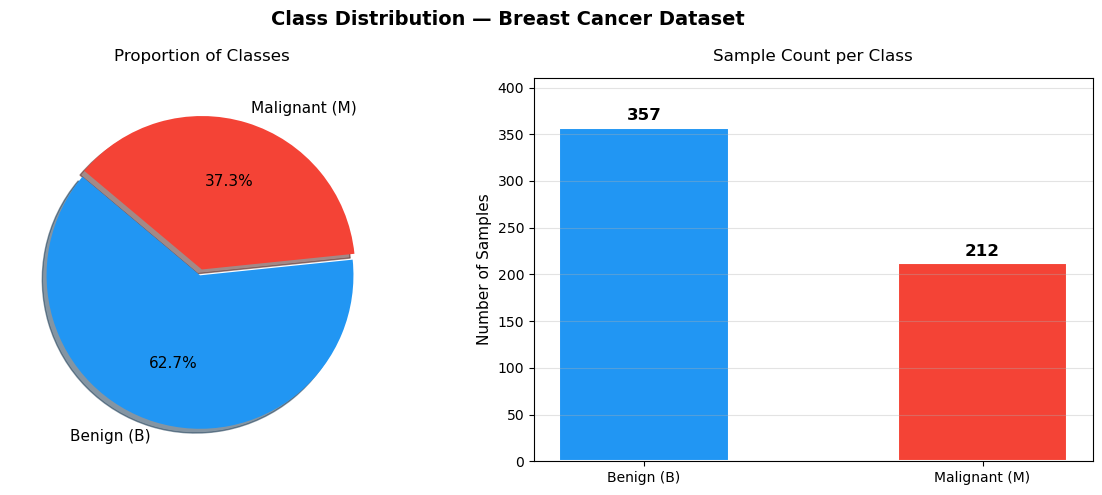

<Figure size 640x480 with 0 Axes>

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\01_class_distribution.png


In [12]:
# ── Plot 1: Class Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution — Breast Cancer Dataset', fontsize=14, fontweight='bold')

labels  = ['Benign (B)', 'Malignant (M)']
sizes   = [class_counts.get('B', 0), class_counts.get('M', 0)]
explode = (0.04, 0)

# Pie
axes[0].pie(sizes, explode=explode, labels=labels, colors=PALETTE,
            autopct='%1.1f%%', startangle=140, shadow=True,
            textprops={'fontsize': 11})
axes[0].set_title('Proportion of Classes', pad=12)

# Bar
bars = axes[1].bar(labels, sizes, color=PALETTE, width=0.5, edgecolor='white', linewidth=1.5)
for bar, size in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(size), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].set_title('Sample Count per Class', pad=12)
axes[1].set_ylim(0, max(sizes) * 1.15)
axes[1].grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.show()
save_plot('01_class_distribution.png')

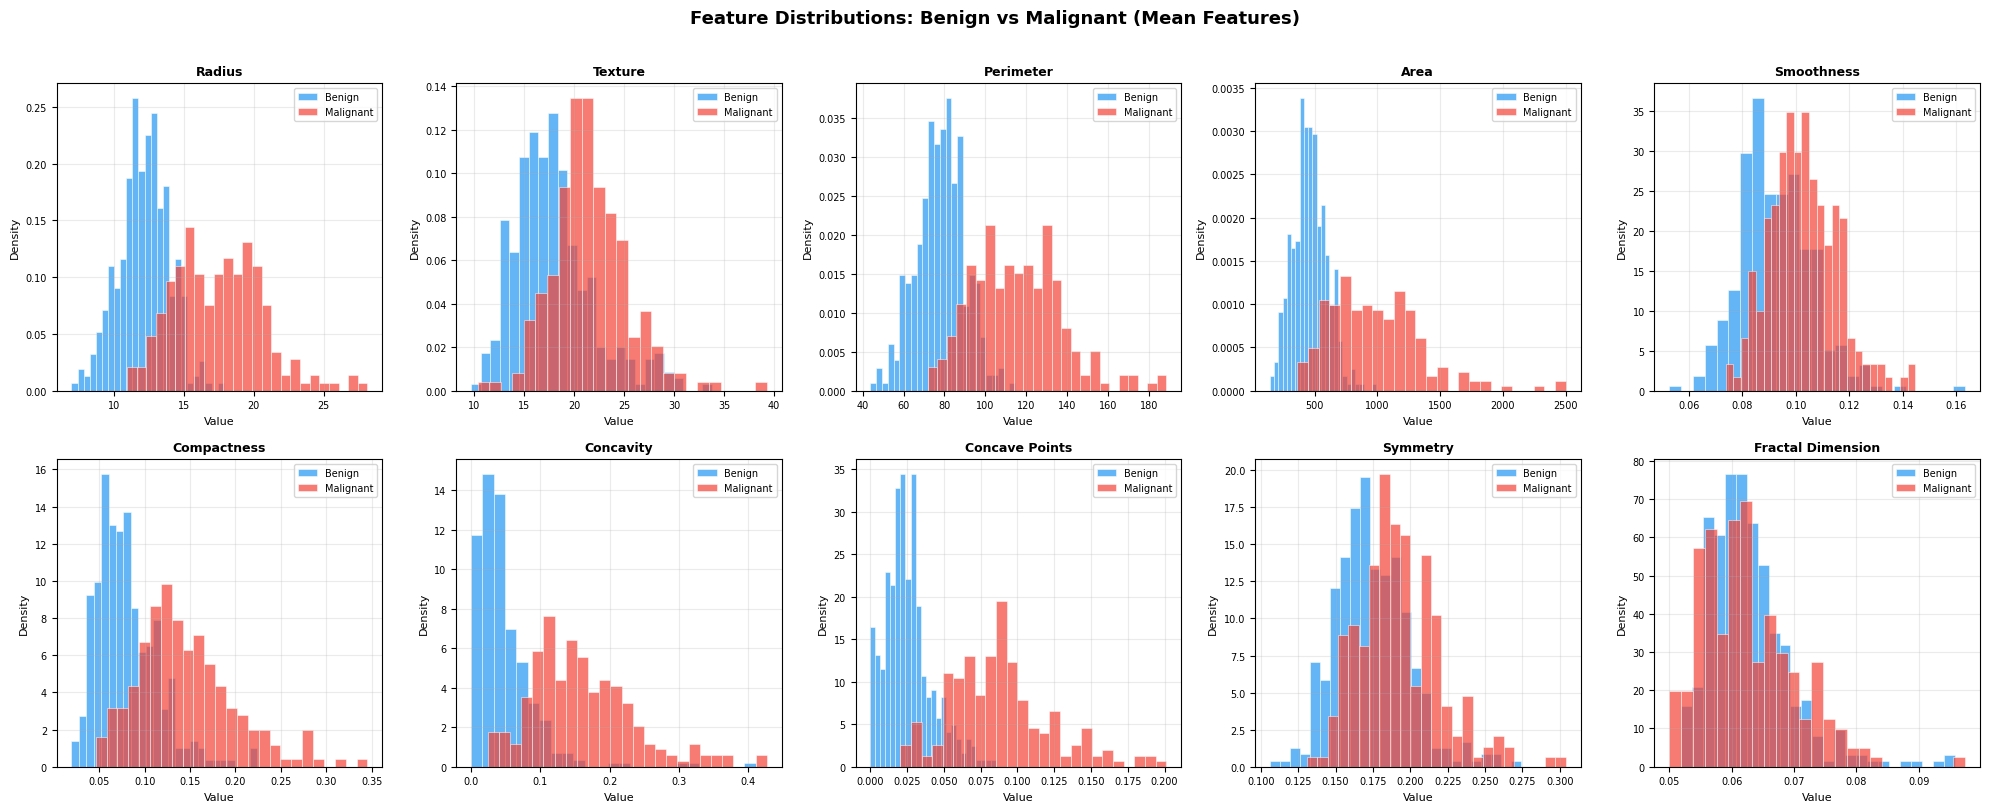

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\02_feature_histograms.png


In [13]:
# ── Plot 2: Feature Histograms (Mean Features) ────────────────────────────────
mean_features = [c for c in feature_cols if c.startswith('mean')]

benign    = df[df['diagnosis_label'] == 'B']
malignant = df[df['diagnosis_label'] == 'M']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Feature Distributions: Benign vs Malignant (Mean Features)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, mean_features):
    ax.hist(benign[feat],    bins=25, alpha=0.7, color=COLORS['B'],
            label='Benign',    density=True, edgecolor='white', linewidth=0.5)
    ax.hist(malignant[feat], bins=25, alpha=0.7, color=COLORS['M'],
            label='Malignant', density=True, edgecolor='white', linewidth=0.5)
    ax.set_title(feat.replace('mean ', '').title(), fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

plt.tight_layout()
save_plot('02_feature_histograms.png')
plt.show()

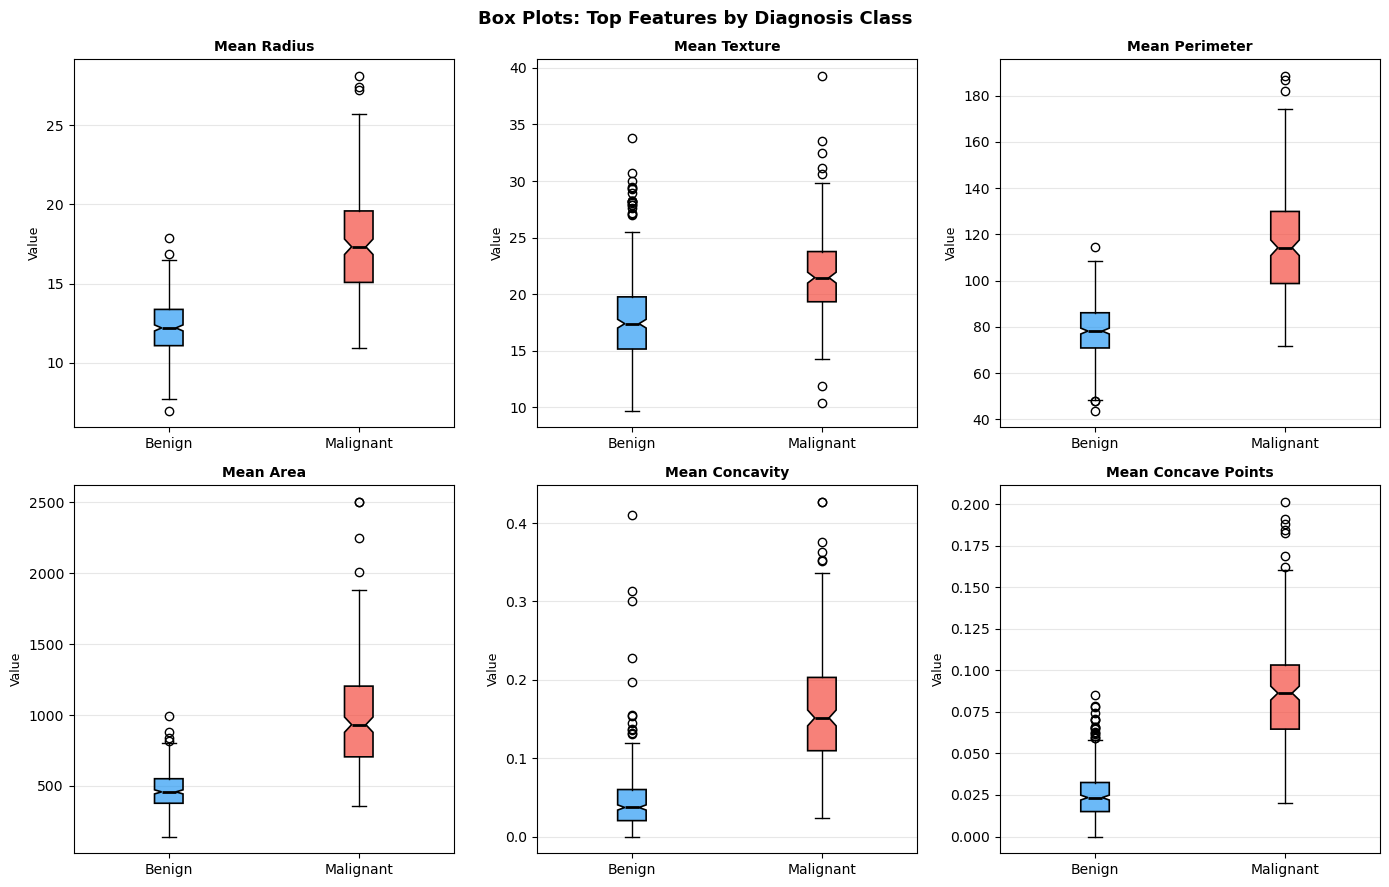

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\03_box_plots.png


In [14]:
# ── Plot 3: Box Plots by Diagnosis ────────────────────────────────────────────
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean concavity', 'mean concave points']

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle('Box Plots: Top Features by Diagnosis Class',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    data_b = benign[feat].values
    data_m = malignant[feat].values
    bp = ax.boxplot([data_b, data_m],
                    labels=['Benign', 'Malignant'],
                    patch_artist=True,
                    notch=True,
                    boxprops=dict(linewidth=1.2),
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(COLORS['B'] + 'AA')
    bp['boxes'][1].set_facecolor(COLORS['M'] + 'AA')
    ax.set_title(feat.title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_plot('03_box_plots.png')
plt.show()

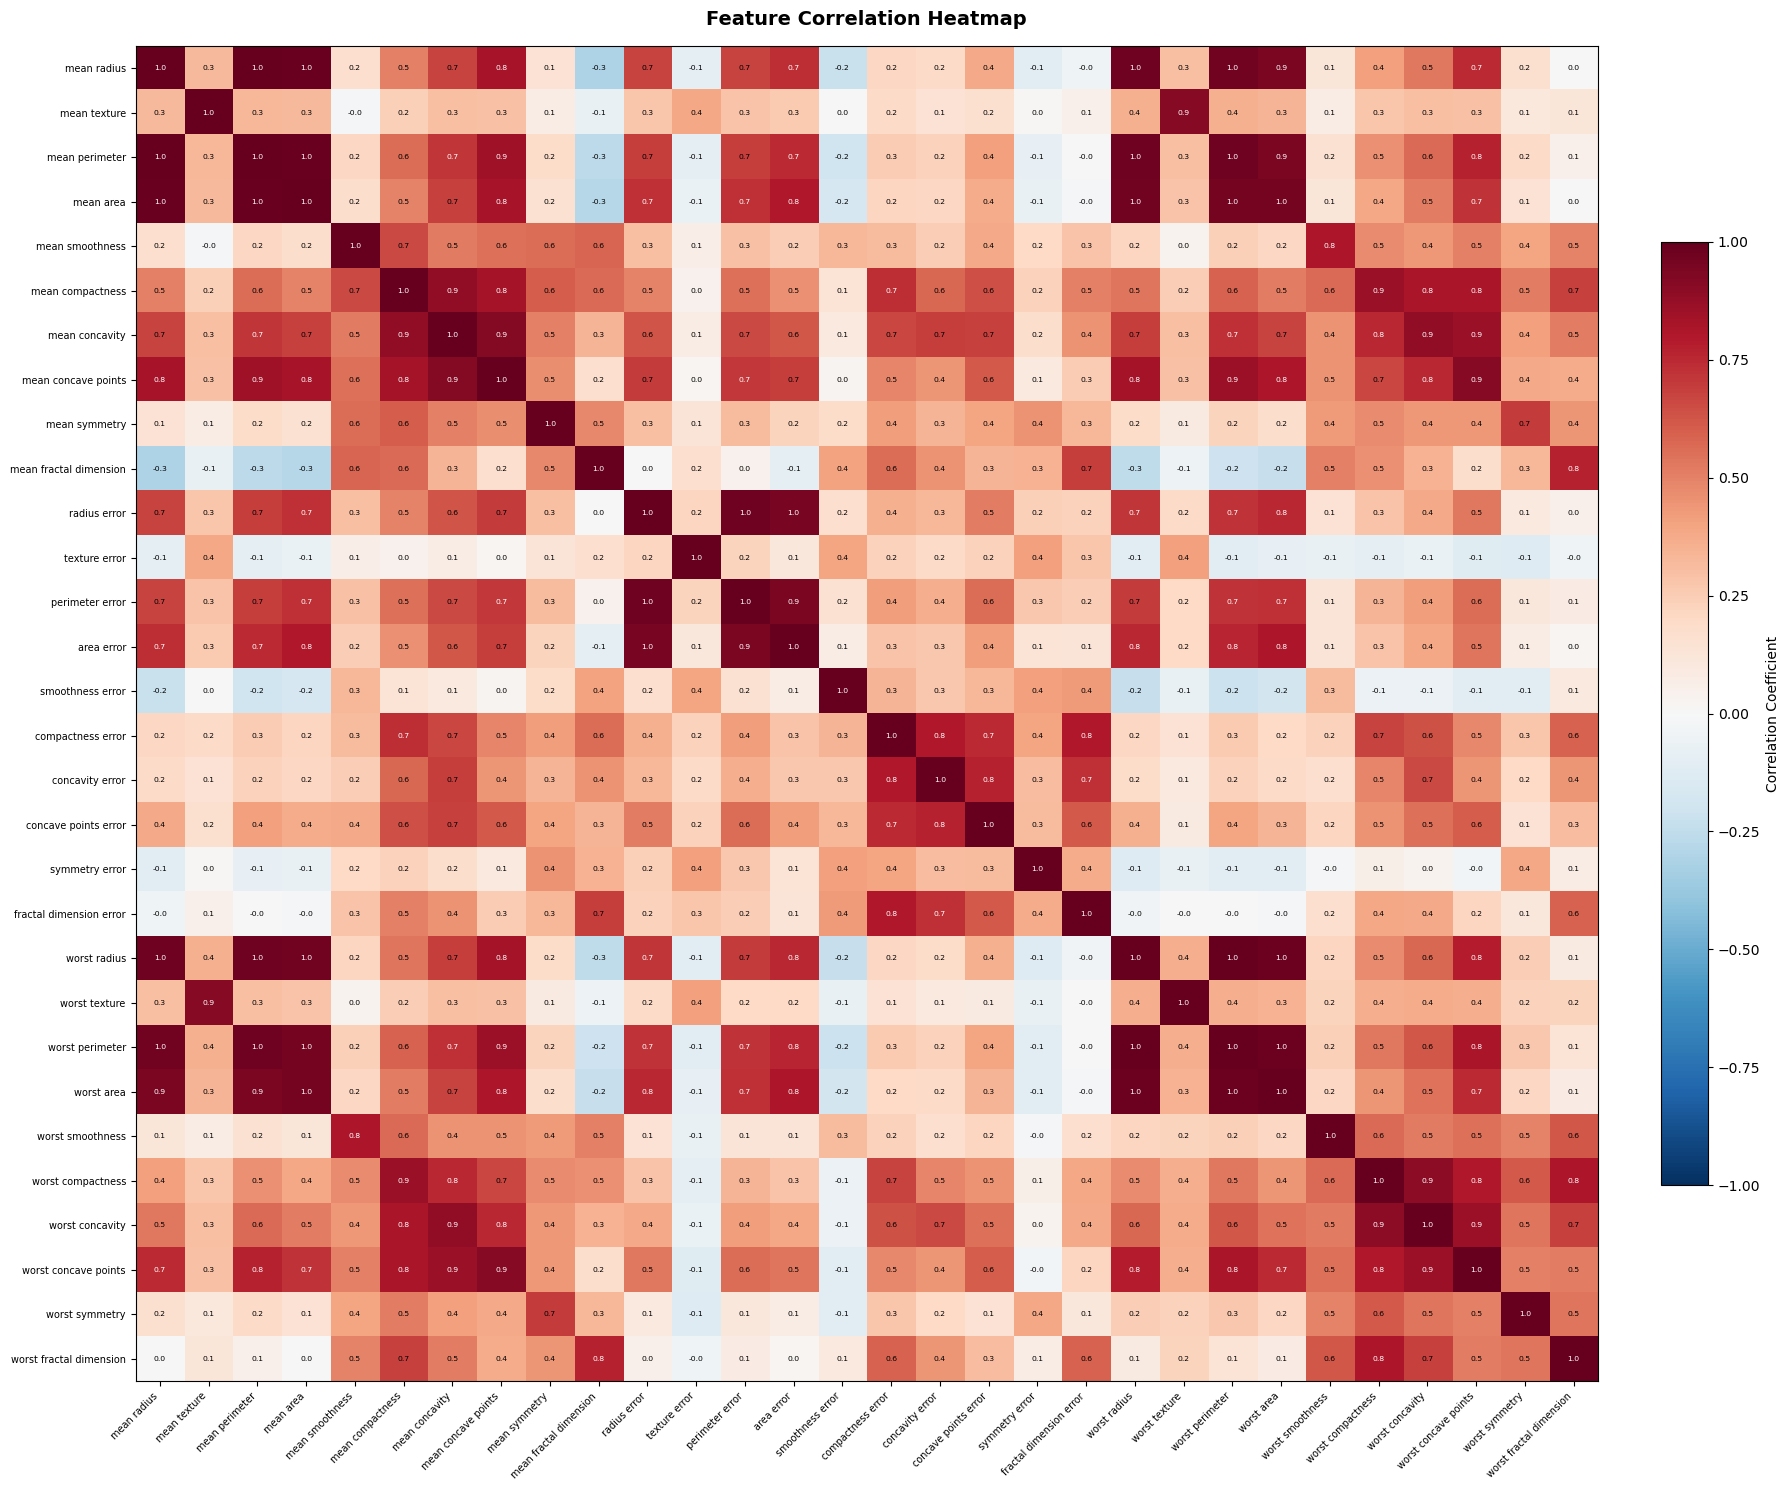

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\04_correlation_heatmap.png


In [15]:
# ── Plot 4: Correlation Heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 15))

corr_matrix = df[feature_cols].corr()

# Manual heatmap using imshow
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Correlation Coefficient')

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(feature_cols, fontsize=7)

# Annotate cells with values
for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.7 else 'black'
        ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                fontsize=5.5, color=color)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
save_plot('04_correlation_heatmap.png', dpi=120)
plt.show()

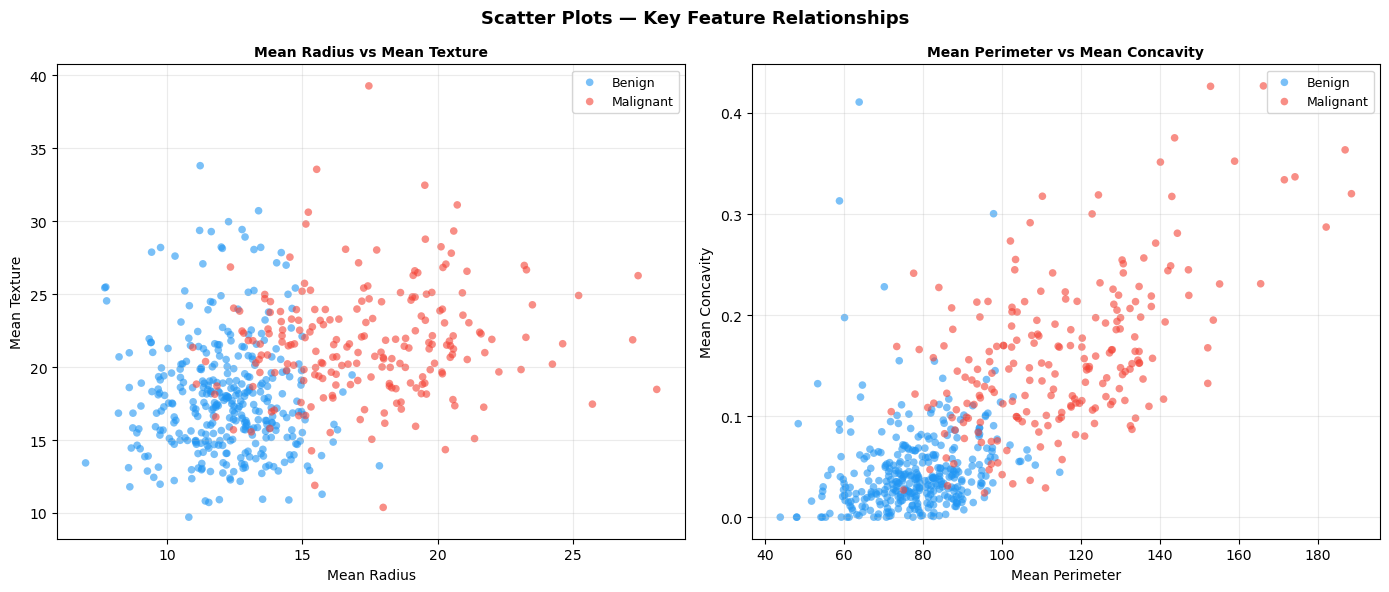

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\06_scatter_plots.png

All 6 visualizations saved to: c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots


In [16]:
# ── Plot 6: Feature Scatter — Radius vs Texture ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Scatter Plots — Key Feature Relationships', fontsize=13, fontweight='bold')

scatter_pairs = [
    ('mean radius', 'mean texture'),
    ('mean perimeter', 'mean concavity'),
]

for ax, (fx, fy) in zip(axes, scatter_pairs):
    for label, color in [('B', COLORS['B']), ('M', COLORS['M'])]:
        subset = df[df['diagnosis_label'] == label]
        ax.scatter(subset[fx], subset[fy], c=color, alpha=0.6, s=30,
                   label='Benign' if label == 'B' else 'Malignant',
                   edgecolors='none')
    ax.set_xlabel(fx.title(), fontsize=10)
    ax.set_ylabel(fy.title(), fontsize=10)
    ax.set_title(f'{fx.title()} vs {fy.title()}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
save_plot('06_scatter_plots.png')
plt.show()

print(f'\nAll 6 visualizations saved to: {PLOTS_DIR}')

5. Data Preprocessing

In [17]:
X = df[feature_cols].values
y = df['diagnosis'].values

print(f'Features matrix  X : {X.shape}')
print(f'Target vector    y : {y.shape}')
print(f'Unique labels      : {np.unique(y)}  (0=Malignant, 1=Benign)')

Features matrix  X : (569, 30)
Target vector    y : (569,)
Unique labels      : [0 1]  (0=Malignant, 1=Benign)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'\nClass balance in training set:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = 'Malignant' if u == 0 else 'Benign'
    print(f'  {label} ({u}): {c}  ({c/len(y_train)*100:.1f}%)')

Training set   : 455 samples
Test set       : 114 samples

Class balance in training set:
  Malignant (0): 170  (37.4%)
  Benign (1): 285  (62.6%)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied.')
print(f'   Train set — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}')
print(f'   Test set  — mean: {X_test_scaled.mean():.4f},  std: {X_test_scaled.std():.4f}')
#Ignore test set, as it is not scaled for training. Its use is for test only.

StandardScaler applied.
   Train set — mean: -0.0000, std: 1.0000
   Test set  — mean: 0.0296,  std: 0.9626

   (Test set stats ≠ exactly 0/1 — expected, scaler fitted on train only)


6. Build ANN

In [20]:
def build_ann(input_dim: int) -> keras.Model:
    """Build and compile the ANN architecture."""
    model = keras.Sequential([
        # ── Input Layer ─────────────────────────────────────────────────────
        layers.Input(shape=(input_dim,), name='input'),

        # ── Hidden Layer 1 ──────────────────────────────────────────────────
        layers.Dense(128, name='dense_1',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(name='bn_1'),
        layers.Activation('relu', name='relu_1'),
        layers.Dropout(0.30, name='dropout_1', seed=SEED),

        # ── Hidden Layer 2 ──────────────────────────────────────────────────
        layers.Dense(64, name='dense_2',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(name='bn_2'),
        layers.Activation('relu', name='relu_2'),
        layers.Dropout(0.25, name='dropout_2', seed=SEED),

        # ── Hidden Layer 3 ──────────────────────────────────────────────────
        layers.Dense(32, name='dense_3'),
        layers.BatchNormalization(name='bn_3'),
        layers.Activation('relu', name='relu_3'),
        layers.Dropout(0.20, name='dropout_3', seed=SEED),

        # ── Output Layer ────────────────────────────────────────────────────
        layers.Dense(1, activation='sigmoid', name='output'),
    ], name='BreastCancer_ANN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model


# Build model
model = build_ann(input_dim=X_train_scaled.shape[1])
model.summary()

Model: "BreastCancer_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

7. Training the Model

In [22]:
# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH, monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

# ── Train ─────────────────────────────────────────────────────────────────────
print('Training started…\n')
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining complete!')
print(f'   Epochs run  : {len(history.history["loss"])}')
print(f'   Best val acc: {max(history.history["val_accuracy"]):.4f}')

Training started…

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9948 - loss: 0.1208 - precision: 0.9959 - recall: 0.9959 - val_accuracy: 0.9710 - val_loss: 0.1425 - val_precision: 1.0000 - val_recall: 0.9487 - learning_rate: 2.5000e-04
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9948 - loss: 0.1266 - precision: 0.9959 - recall: 0.9959 - val_accuracy: 0.9710 - val_loss: 0.1440 - val_precision: 1.0000 - val_recall: 0.9487 - learning_rate: 2.5000e-04
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9922 - loss: 0.1308 - precision: 0.9959 - recall: 0.9919 - val_accuracy: 0.9855 - val_loss: 0.1455 - val_precision: 1.0000 - val_recall: 0.9744 - learning_rate: 2.5000e-04
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9948 - loss: 0.1212 - precision: 0.9959 - recall: 0.9959 - val_accuracy: 0.9855 - val_loss: 0.1464 - val_precision: 1.0000 - val_recall: 0.9744 - learning_rate: 2.5000e-04
Epoch 5/200
13/13 ━━━━━━━━━━━

8. Training History Visualization

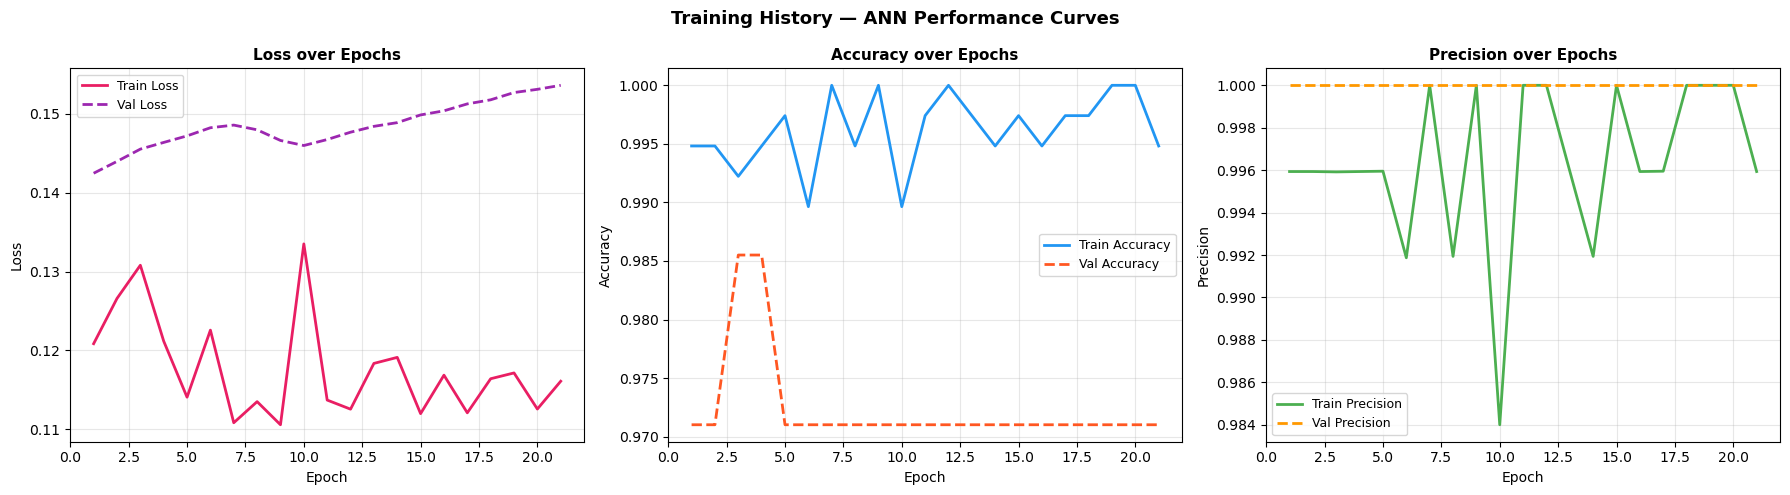

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\07_training_history.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — ANN Performance Curves',
             fontsize=13, fontweight='bold')

metrics_to_plot = [
    ('loss',      'val_loss',      'Loss',      '#E91E63', '#9C27B0'),
    ('accuracy',  'val_accuracy',  'Accuracy',  '#2196F3', '#FF5722'),
    ('precision', 'val_precision', 'Precision', '#4CAF50', '#FF9800'),
]

for ax, (train_key, val_key, title, tc, vc) in zip(axes, metrics_to_plot):
    epochs = range(1, len(history.history[train_key]) + 1)
    ax.plot(epochs, history.history[train_key],  color=tc, linewidth=2, label=f'Train {title}')
    ax.plot(epochs, history.history[val_key],    color=vc, linewidth=2,
            linestyle='--', label=f'Val {title}')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(f'{title} over Epochs', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
save_plot('07_training_history.png')

9. Model Testing

In [24]:
# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_proba = model.predict(X_test_scaled, verbose=0).flatten()
y_pred       = (y_pred_proba >= 0.5).astype(int)

# ── Compute Metrics ───────────────────────────────────────────────────────────
metrics = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall'   : recall_score(y_test, y_pred,    zero_division=0),
    'f1_score' : f1_score(y_test, y_pred,        zero_division=0),
    'roc_auc'  : roc_auc_score(y_test, y_pred_proba),
}

# ── Print Report ──────────────────────────────────────────────────────────────
print('=' * 50)
print('  MODEL EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy    : {metrics["accuracy"]:.4f}  ({metrics["accuracy"]*100:.2f}%)')
print(f'  Precision   : {metrics["precision"]:.4f}')
print(f'  Recall      : {metrics["recall"]:.4f}')
print(f'  F1 Score    : {metrics["f1_score"]:.4f}')
print(f'  ROC-AUC     : {metrics["roc_auc"]:.4f}')
print('=' * 50)
print()
print('  Detailed Classification Report:')
print('─' * 50)
target_names = ['Malignant (0)', 'Benign (1)']
report_str   = classification_report(y_test, y_pred, target_names=target_names)
print(report_str)

  MODEL EVALUATION RESULTS
  Accuracy    : 0.9649  (96.49%)
  Precision   : 0.9857
  Recall      : 0.9583
  F1 Score    : 0.9718
  ROC-AUC     : 0.9950

  Detailed Classification Report:
──────────────────────────────────────────────────
               precision    recall  f1-score   support

Malignant (0)       0.93      0.98      0.95        42
   Benign (1)       0.99      0.96      0.97        72

     accuracy                           0.96       114
    macro avg       0.96      0.97      0.96       114
 weighted avg       0.97      0.96      0.97       114



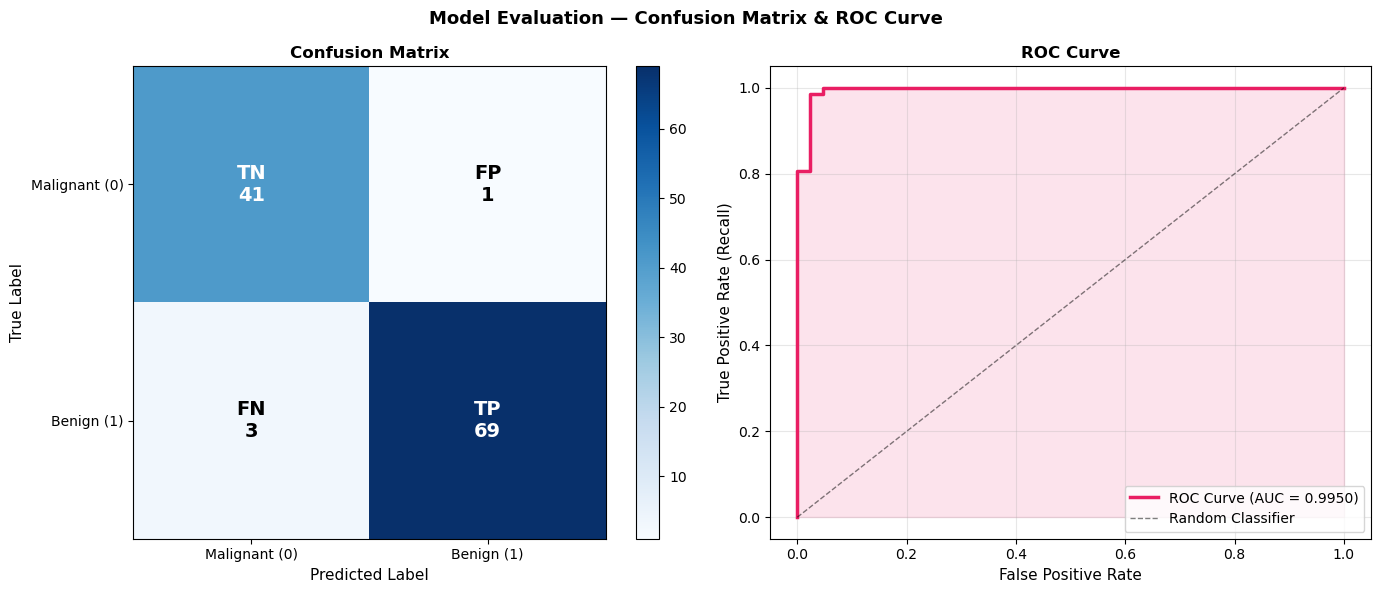

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\08_confusion_matrix_roc.png


In [25]:
# ── Plot: Confusion Matrix + ROC Curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Evaluation — Confusion Matrix & ROC Curve',
             fontsize=13, fontweight='bold')

# ─ Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Malignant (0)', 'Benign (1)'], fontsize=10)
axes[0].set_yticklabels(['Malignant (0)', 'Benign (1)'], fontsize=10)

cell_labels = [['TN', 'FP'], ['FN', 'TP']]
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > thresh else 'black'
        axes[0].text(j, i, f'{cell_labels[i][j]}\n{cm[i, j]}',
                     ha='center', va='center', fontsize=14,
                     fontweight='bold', color=color)

axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ─ ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#E91E63', linewidth=2.5,
             label=f'ROC Curve (AUC = {metrics["roc_auc"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#E91E63')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
save_plot('08_confusion_matrix_roc.png')

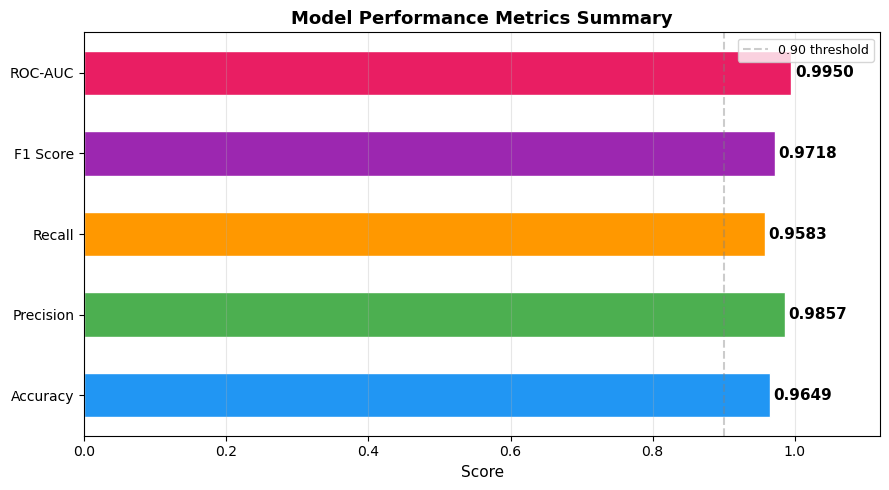

   💾 Saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\plots\09_metrics_summary.png


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
metric_values = [metrics['accuracy'], metrics['precision'],
                 metrics['recall'],   metrics['f1_score'], metrics['roc_auc']]
bar_colors    = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']

bars = ax.barh(metric_names, metric_values, color=bar_colors, height=0.55, edgecolor='white')
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, 1.12)
ax.set_xlabel('Score', fontsize=11)
ax.set_title('Model Performance Metrics Summary', fontsize=13, fontweight='bold')
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4, label='0.90 threshold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_plot('09_metrics_summary.png')

10. Saving Metrics and building predicion system

In [27]:
model.save(MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

metrics_payload = {
    'model_name'   : 'BreastCancer_ANN',
    'test_samples' : int(len(y_test)),
    'accuracy'     : float(round(metrics['accuracy'],  4)),
    'precision'    : float(round(metrics['precision'], 4)),
    'recall'       : float(round(metrics['recall'],    4)),
    'f1_score'     : float(round(metrics['f1_score'],  4)),
    'roc_auc'      : float(round(metrics['roc_auc'],   4)),
    'epochs_trained': len(history.history['loss']),
    'confusion_matrix': cm.tolist(),
}

metrics_path = os.path.join(METRICS_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_payload, f, indent=2)
print(f'Metrics saved → {metrics_path}')

report_path = os.path.join(METRICS_DIR, 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write('BREAST CANCER ANN — CLASSIFICATION REPORT\n')
    f.write('=' * 48 + '\n\n')
    for k, v in metrics_payload.items():
        if k != 'confusion_matrix':
            f.write(f'{k:<20}: {v}\n')
    f.write('\nDETAILED REPORT:\n')
    f.write('─' * 48 + '\n')
    f.write(classification_report(y_test, y_pred, target_names=target_names))
print(f'Report saved → {report_path}')

Model saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\models\saved_model.keras
Metrics saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\metrics\metrics.json
Report saved → c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\metrics\classification_report.txt


In [28]:
def predict_single(patient_features: np.ndarray,
                   scaler: StandardScaler,
                   model: keras.Model,
                   feature_names: list,
                   threshold: float = 0.5,
                   save_result: bool = True) -> dict:
    """
    Classify a single patient record.

    Args:
        patient_features : 1D array of shape (30,) — raw feature values
        scaler           : Fitted StandardScaler
        model            : Trained Keras model
        feature_names    : List of 30 feature names
        threshold        : Decision boundary (default 0.5)
        save_result      : If True, saves result JSON to outputs/predictions/

    Returns:
        dict with 'label', 'class_name', 'probability', and 'confidence'
    """
    # Validate input
    patient_array = np.array(patient_features, dtype=np.float64).reshape(1, -1)
    if patient_array.shape[1] != 30:
        raise ValueError(f'Expected 30 features, got {patient_array.shape[1]}')

    # Scale
    patient_scaled = scaler.transform(patient_array)

    # Predict
    prob  = float(model.predict(patient_scaled, verbose=0)[0][0])
    label = int(prob >= threshold)
    class_name = 'Benign (B)' if label == 1 else 'Malignant (M)'
    confidence = prob if label == 1 else (1 - prob)

    result = {
        'label'           : label,
        'class_name'      : class_name,
        'probability_benign'   : round(prob, 6),
        'probability_malignant': round(1 - prob, 6),
        'confidence'      : round(confidence, 6),
        'threshold'       : threshold,
    }

    if save_result:
        import time
        ts   = int(time.time())
        path = os.path.join(PREDS_DIR, f'prediction_{ts}.json')
        with open(path, 'w') as f:
            json.dump({'input_features': patient_features.tolist()
                       if hasattr(patient_features, 'tolist') else list(patient_features),
                       **result}, f, indent=2)
        result['saved_to'] = path

    return result


print('predict_single() function defined.')

predict_single() function defined.


In [30]:
print('─' * 55)
print(' DEMO PREDICTION — Known Malignant Sample')
print('─' * 55)

# Pick first malignant sample from test set
malignant_idx = np.where(y_test == 0)[0][0]
patient_1     = X_test[malignant_idx]  # raw (unscaled) features

result_1 = predict_single(patient_1, scaler, model, feature_cols)

print(f'  Ground Truth      : Malignant (0)')
print(f'  Prediction        : {result_1["class_name"]}  (label={result_1["label"]})')
print(f'  P(Benign)         : {result_1["probability_benign"]:.4f}')
print(f'  P(Malignant)      : {result_1["probability_malignant"]:.4f}')
print(f'  Confidence        : {result_1["confidence"]*100:.2f}%')
print(f'  Result saved to   : {result_1.get("saved_to", "N/A")}')
print()

print('─' * 55)
print(' DEMO PREDICTION — Known Benign Sample')
print('─' * 55)

benign_idx = np.where(y_test == 1)[0][0]
patient_2  = X_test[benign_idx]

result_2 = predict_single(patient_2, scaler, model, feature_cols)

print(f'  Ground Truth      : Benign (1)')
print(f'  Prediction        : {result_2["class_name"]}  (label={result_2["label"]})')
print(f'  P(Benign)         : {result_2["probability_benign"]:.4f}')
print(f'  P(Malignant)      : {result_2["probability_malignant"]:.4f}')
print(f'  Confidence        : {result_2["confidence"]*100:.2f}%')
print(f'  Result saved to   : {result_2.get("saved_to", "N/A")}')

───────────────────────────────────────────────────────
 DEMO PREDICTION — Known Malignant Sample
───────────────────────────────────────────────────────
  Ground Truth      : Malignant (0)
  Prediction        : Malignant (M)  (label=0)
  P(Benign)         : 0.0108
  P(Malignant)      : 0.9892
  Confidence        : 98.92%
  Result saved to   : c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\predictions\prediction_1782325822.json

───────────────────────────────────────────────────────
 DEMO PREDICTION — Known Benign Sample
───────────────────────────────────────────────────────
  Ground Truth      : Benign (1)
  Prediction        : Benign (B)  (label=1)
  P(Benign)         : 0.9999
  P(Malignant)      : 0.0001
  Confidence        : 99.99%
  Result saved to   : c:\Users\Udbhav\Documents\ML-Projects\Breat-Cancer-Detection\outputs\predictions\prediction_1782325822.json
